## Analyzing the step input data from webots for Modelling

In [97]:
import pandas as pd 
import numpy as np
from scipy.linalg import expm

In [19]:
data  = []

with open('step_input5_30' , 'r') as f:
    for lines in f:
        data.append(list(map(lambda x: float(x) , lines.strip().split(','))))
        
df = pd.DataFrame(data)

In [31]:
df.rename(columns={0:'time' , 
                   1: 'ax' ,
                   2: 'ay' ,
                   3: 'az' ,
                   4: 'sx',
                   5: 'sy' ,
                   6: 'sz' ,
                   7: 'px' ,
                   8: 'py' ,
                   9: 'pz'} , inplace=True)

df.set_index('time' , inplace=True)
df.head()

,ax,ay,az,sx,sy,sz,px,py,pz
time,,,,,,,,,
0.05,-288.379000,1.191210e-06,9.10019,0.001055,-2.792220e-09,-0.056268,-34.8189,6.70001,0.439641
0.10,0.004002,1.602070e-10,9.41177,0.002622,-6.937380e-09,-0.063487,-34.8188,6.70001,0.436467
0.15,0.011187,4.534660e-10,9.87372,0.004052,-1.072700e-08,-0.049873,-34.8186,6.70001,0.433973
0.20,0.023583,6.408160e-10,10.05460,0.005081,-1.346090e-08,-0.030090,-34.8183,6.70001,0.432469
0.25,0.036833,7.022810e-10,10.09540,0.005666,-1.502840e-08,-0.011235,-34.8181,6.70001,0.431907


<Axes: xlabel='time'>

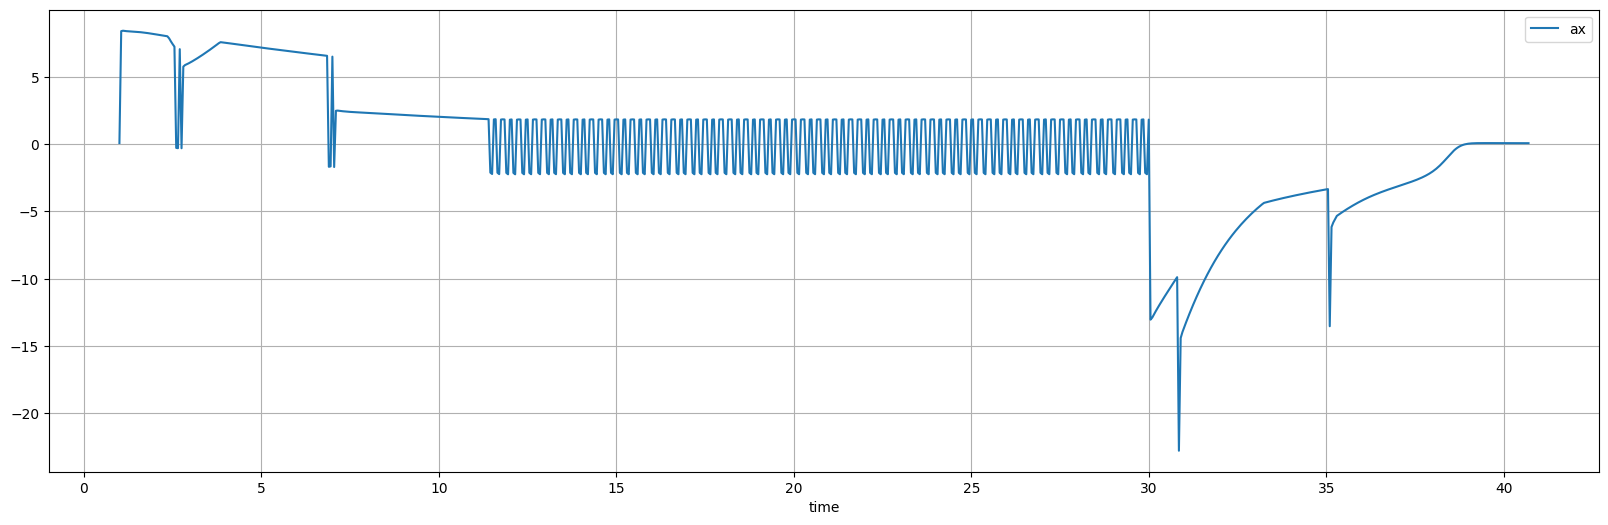

In [132]:
show = ['ax']
df[show].loc[1:].plot(figsize=(20,6) , grid=True)

<Axes: >

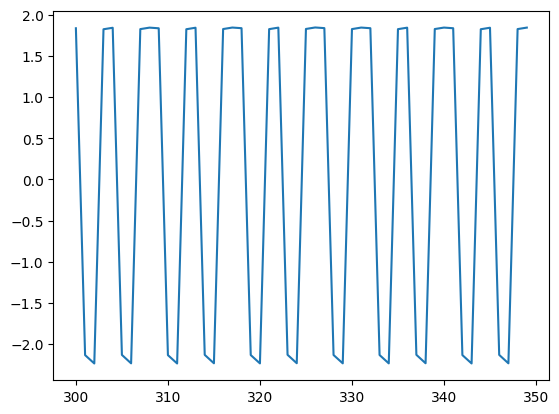

In [22]:
df.ax.iloc[300:350].plot()

## Model prediction

In [ ]:
t1 = 0.2
# t2 = 0.1
k1 = 0.8
# k2 = 4
thw = 2

"""     Discrete A
         1       0.05 -0.0932943
         0          1 -0.0460555
         0          0   0.846482
"""

""" B: 
    -0.00636454
    -0.00315561
    0.122815
"""

<Axes: >

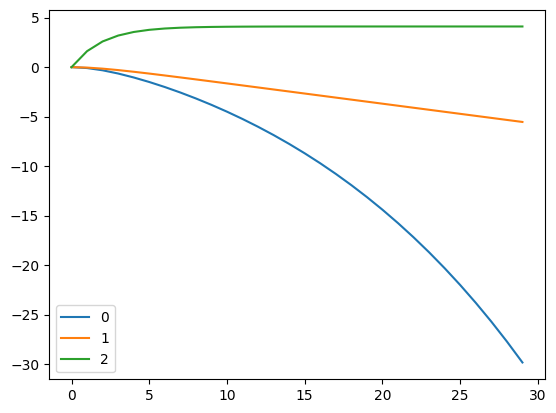

In [134]:
t1 = 0.1
# t2 = 0.1
k1 = 4
dt = 0.05

A = np.array([[1 , 1 , -thw] , [0 , 0 , -1] , [0 , 0 , -1/t1]])
B = np.array([0 , 0 , k1/t1]).reshape(3,1)
C = np.identity(3) 

xx = np.array([0,0,0,1]).reshape(1,4)
yy = np.append(A , B , axis=1)
# print(f" { xx.shape}    {yy.shape}")

AB = np.append( yy , xx , axis=0)

eAB = expm(AB * dt)
Ad = eAB[0:3,0:3]
Bd = eAB[0:3,3]

u = np.ones(50)
ax = np.zeros((51,3))

for i in range(len(u)):
    ax[i+1] = Ad @ ax[i] + Bd * u[i]
    
pd.DataFrame(ax).iloc[0:30].plot()